In [6]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:100% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

※ naver open API를 활용하여 네이버지식인 "전주여행"과 "경주여행"을 검색 -> 명사만 추출(re ? ) -> 품사태깅 백업, 명사만 추출 -> 빈도분석(DataFrame) -> 빈도 시각화(워드클라우드, Text) -> Word2Vec
1. 네이버 open API를 활용하여 검색 추출
검색어, no, title, link, description, title + ' ' + description

In [7]:
import os
os.getcwd()   # 현재 작업디렉토리

'C:\\Ai_x\\source\\자연어처리'

In [8]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\Ai_x\source\자연어처리 디렉터리

2025-05-30  오후 01:05               362 .env
               1개 파일                 362 바이트
               0개 디렉터리  109,347,061,760 바이트 남음


In [9]:
from dotenv import load_dotenv
load_dotenv()

print(os.getenv('Client_ID'))
print(os.getenv('Client_Secret'))

kR2eV3UA7Rr0Xsbhw6Lg
9QtPFx7C4p


In [10]:
from decouple import config
print(config('Client_ID'))
print(os.getenv('Client_Secret'))

kR2eV3UA7Rr0Xsbhw6Lg
9QtPFx7C4p


In [19]:
import os
import sys
import urllib.request
from konlpy.tag import Okt  # 품사 태깅을 위한 라이브러리

# 네이버 API 키 설정
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')

# 검색할 문구 설정
queries = ["전주여행", "경주여행"]

# Okt 객체 생성
okt = Okt()

# text 변수 초기화 (제목을 저장할 변수)
text = ""

# 검색어마다 API 요청 처리
for query in queries:
    encText = urllib.parse.quote(query)
    data = "source=ko&target=en&text=" + encText
    url = f"https://openapi.naver.com/v1/search/kin.json?query={encText}"

    # API 요청 헤더 설정
    headers = {'X-Naver-Client-Id': client_id,
              'X-Naver-Client-Secret': client_secret}
    request = urllib.request.Request(url, headers=headers)

    # 요청 보내고 응답 코드 확인
    response = urllib.request.urlopen(request)
    rescode = response.getcode()

    if rescode == 200:
        response_body = response.read()
        response_text = response_body.decode('utf-8')
        
        # JSON 응답 처리
        import json
        data = json.loads(response_text)
        
        # 검색한 제목 추출 
        titles = [item['title'] for item in data['items']]
        
        # 각 제목을 text 변수에 이어서 저장
        for title in titles:
            print(f"원본 제목: {title}")
            text += title + " "  # 제목을 text에 이어서 추가

        # 품사 태깅
        print(f"\n검색어: {query}")
        for title in titles:
            print(f"품사 태깅: {okt.pos(title)}")  # 품사 태깅 결과 출력
            
    else:
        print(f"Error Code: {rescode} for {query}")

# 최종적으로 저장된 text 출력
print("\n전체 저장된 제목:")
print(text)


원본 제목: <b>전주</b> 가볼만한곳 추천 받아요
원본 제목: <b>전주여행</b>갈려고하는데요!
원본 제목: <b>전주</b> 1박 2일 <b>여행</b> 관련 질문~
원본 제목: 중2 여학생 친구와 <b>전주여행</b>
원본 제목: 부모닝 모시고 <b>전주여행</b>
원본 제목: <b>전주</b> 1박2일 <b>여행</b>
원본 제목: 2박3일 <b>전주여행</b>
원본 제목: <b>전주 여행</b>코스 추천이요~!
원본 제목: 추석 <b>전주여행</b>
원본 제목: <b>전주 여행</b>

검색어: 전주여행
품사 태깅: [('<', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('전주', 'Noun'), ('</', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('가볼만', 'Verb'), ('한', 'Determiner'), ('곳', 'Noun'), ('추천', 'Noun'), ('받아요', 'Verb')]
품사 태깅: [('<', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('전주', 'Noun'), ('여행', 'Noun'), ('</', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('갈려고하는데요', 'Verb'), ('!', 'Punctuation')]
품사 태깅: [('<', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('전주', 'Noun'), ('</', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('1', 'Number'), ('박', 'Noun'), ('2일', 'Number'), ('<', 'Punctuation'), ('b', 'Alpha'), ('>', 'Punctuation'), ('여행', 'Noun'), ('

In [21]:
print(kkma.nouns(text)) 

['전주', '곳', '추천', '전주여행', '여행', '1', '1박', '박', '2', '2일', '일', '관련', '질문', '중', '중2', '여', '여학생', '학생', '친구', '부', '부모닝', '모닝', '1박2일', '2박3일', '3', '코스', '추천이요', '이요', '추석', '경주', '일정', '주세', '어머니', '경주여행', '30', '30만원', '만', '원', '맛', '맛집', '집', '을', '2월', '월', '날씨', '카페', '고민']


In [22]:
print(kkma.pos(text))

[('<', 'SS'), ('b', 'OL'), ('>', 'SS'), ('전주', 'NNG'), ('<', 'SS'), ('/', 'SP'), ('b', 'OL'), ('>', 'SS'), ('가보', 'VV'), ('ㄹ', 'ETD'), ('만하', 'VXA'), ('ㄴ', 'ETD'), ('곳', 'NNG'), ('추천', 'NNG'), ('받', 'VV'), ('아요', 'EFN'), ('<', 'SS'), ('b', 'OL'), ('>', 'SS'), ('전주', 'NNG'), ('여행', 'NNG'), ('<', 'SS'), ('/', 'SP'), ('b', 'OL'), ('>', 'SS'), ('갈', 'VV'), ('려고', 'ECD'), ('하', 'VV'), ('는데요', 'ECD'), ('!', 'SF'), ('<', 'SS'), ('b', 'OL'), ('>', 'SS'), ('전주', 'NNG'), ('<', 'SS'), ('/', 'SP'), ('b', 'OL'), ('>', 'SS'), ('1', 'NR'), ('박', 'NNM'), ('2', 'NR'), ('일', 'NNM'), ('<', 'SS'), ('b', 'OL'), ('>', 'SS'), ('여행', 'NNG'), ('<', 'SS'), ('/', 'SP'), ('b', 'OL'), ('>', 'SS'), ('관련', 'NNG'), ('질문', 'NNG'), ('~', 'SO'), ('중', 'NNB'), ('2', 'NR'), ('여', 'NNG'), ('학생', 'NNG'), ('친구', 'NNG'), ('와', 'JC'), ('<', 'SS'), ('b', 'OL'), ('>', 'SS'), ('전주', 'NNG'), ('여행', 'NNG'), ('<', 'SS'), ('/', 'SP'), ('b', 'OL'), ('>', 'SS'), ('부', 'NNG'), ('모닝', 'NNG'), ('모시', 'VV'), ('고', 'ECE'), ('<', 'SS'), ('b'

In [30]:
tagged_text = kkma.pos(text)
print([word for word, tag in tagged_text if tag in ('NNG','NNP','NNB','NNM') ])
print(kkma.nouns(text))
nouns = kkma.nouns(text)
nouns

['전주', '곳', '추천', '전주', '여행', '전주', '박', '일', '여행', '관련', '질문', '중', '여', '학생', '친구', '전주', '여행', '부', '모닝', '전주', '여행', '전주', '박', '일', '여행', '박', '일', '전주', '여행', '전주', '여행', '코스', '추천', '이요', '추석', '전주', '여행', '전주', '여행', '추석', '경주', '여행', '박', '일', '경주', '여행', '일정', '주세', '어머니', '박', '일', '경주', '여행', '경주', '여행', '경주', '여행', '원', '경주', '여행', '맛', '집', '경주', '여행', '을', '곳', '추천', '월', '일', '경주', '여행', '날씨', '경주', '여행', '중', '맛', '집', '카페', '박', '일', '경주', '여행', '일정', '고민']
['전주', '곳', '추천', '전주여행', '여행', '1', '1박', '박', '2', '2일', '일', '관련', '질문', '중', '중2', '여', '여학생', '학생', '친구', '부', '부모닝', '모닝', '1박2일', '2박3일', '3', '코스', '추천이요', '이요', '추석', '경주', '일정', '주세', '어머니', '경주여행', '30', '30만원', '만', '원', '맛', '맛집', '집', '을', '2월', '월', '날씨', '카페', '고민']


['전주',
 '곳',
 '추천',
 '전주여행',
 '여행',
 '1',
 '1박',
 '박',
 '2',
 '2일',
 '일',
 '관련',
 '질문',
 '중',
 '중2',
 '여',
 '여학생',
 '학생',
 '친구',
 '부',
 '부모닝',
 '모닝',
 '1박2일',
 '2박3일',
 '3',
 '코스',
 '추천이요',
 '이요',
 '추석',
 '경주',
 '일정',
 '주세',
 '어머니',
 '경주여행',
 '30',
 '30만원',
 '만',
 '원',
 '맛',
 '맛집',
 '집',
 '을',
 '2월',
 '월',
 '날씨',
 '카페',
 '고민']

In [24]:
print([word for word, tag in tagged_text if tag in ('NNG','NNP') ])

['전주', '곳', '추천', '전주', '여행', '전주', '여행', '관련', '질문', '여', '학생', '친구', '전주', '여행', '부', '모닝', '전주', '여행', '전주', '여행', '전주', '여행', '전주', '여행', '코스', '추천', '이요', '추석', '전주', '여행', '전주', '여행', '추석', '경주', '여행', '경주', '여행', '일정', '주세', '어머니', '경주', '여행', '경주', '여행', '경주', '여행', '경주', '여행', '맛', '집', '경주', '여행', '을', '곳', '추천', '경주', '여행', '날씨', '경주', '여행', '맛', '집', '카페', '경주', '여행', '일정', '고민']


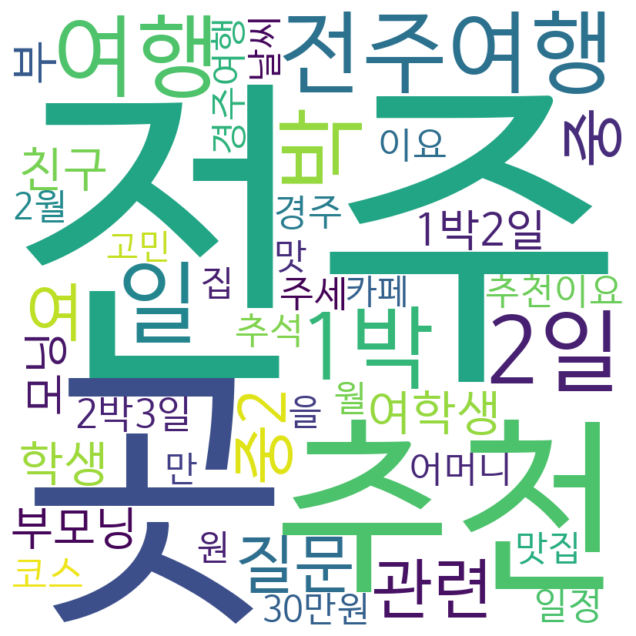

In [33]:
text = ' '.join(nouns)


wordcloud = WordCloud(font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf', 
                      width=800, height=800, 
                      background_color='white').generate(text)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

(1124, 720, 3)


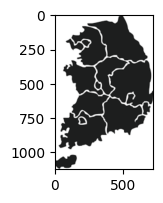

In [38]:
# convert('RGB') : 1채널이미지 ->3채널
# convert('RGBA') : 1채널이미지 -> 4채널(RGB+투명도채널)
from PIL import Image
import numpy as np
img = Image.open('data/south_korea.png').convert('RGB')
mask5 = np.array(img)
print(mask5.shape)
plt.figure(figsize=(2,2))
plt.imshow(mask5)

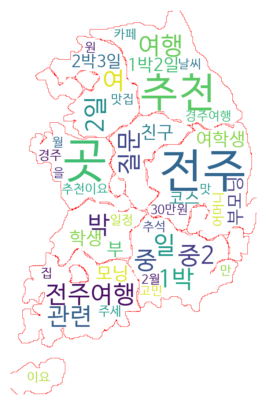

In [41]:
text = ' '.join(nouns)

# 워드클라우드 생성
wordcloud = WordCloud(
    font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',  # 한글 폰트 경로
    background_color='white',  # 배경색
    max_words=300,  # 표시될 단어의 최대 갯수
    colormap='viridis',  # 글씨 컬러맵
    mask=mask5,  # 마스크 이미지 없을 때
    contour_color='red',  # 테두리 색상
    contour_width=1  # 테두리 두께
)

# 문자열을 워드클라우드 생성
wordcloud.generate(text)

# 워드클라우드 시각화
plt.figure(figsize=(18,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [42]:
# 네이버 API 계정 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
queries = ['전주 여행', '경주 여행']
max_start = 5

In [53]:
# 패키지 import
import requests
import time
import os
import json # response 텍스트를 json 딕셔너리로
from html import unescape # description에 있는 &lt;(특수문자)을 <으로 변경, &gt;-> >
import pandas as pd
import re

In [54]:
# 방법1
def get_search_element_save(query, start):
    headers = {'X-Naver-Client-Id':client_id,
           'X-Naver-Client-Secret':client_secret}
    url = f'https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}'
    response = requests.get(url, headers=headers)
    items = json.loads(response.text)['items']
    for i, item in enumerate(items):
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
#         print('수정전 :', description)
        description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description)
#         print('수정후 :', description)
        # print(query, (start*100+i+1), title, link, description, title+' ' +description)
        with open(file_name, 'a', encoding='utf-8') as file:
            file.write('{}\t{}\t{}\t{}\t{}\t{}\n'.format(query, 
                                                         (start-1)*100+i+1,
                                                         title,
                                                         link,
                                                         description, 
                                                         title + ' ' +description))

In [55]:
# 데이터를 저장할 파일 생성 (naver_kin.txt)하고 title 저장(header저장)
file_name = 'data/naver_kin.csv'
with open(file_name, 'w', encoding='utf-8') as file:
    file.write('{}\t{}\t{}\t{}\t{}\t{}\n'.format('query', 
                            'no','title','link', 'description', 'total_text'))

In [72]:
import requests  # requests 모듈 추가
import time

for query in queries:
    for start in range(1, max_start+1):
        print(start, query, '읽는 중')
        get_search_element_save(query, start)
        time.sleep(0.5)

1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
5 전주 여행 읽는 중
1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중
5 경주 여행 읽는 중


In [73]:
import pandas as pd
df = pd.read_csv('data/naver_kin.csv', sep='\t')
df

,query,no,title,link,description,total_text
0,전주 여행,1,전주 가볼만한곳 추천 받아요,https://kin.naver.com/qna/detail.naver?d1id=9&...,추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전...,전주 가볼만한곳 추천 받아요 추억의 7080 다양한체험 7080감성 추억여행 ...
1,전주 여행,2,전주여행 갈려고하는데요!,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2...,전주여행 갈려고하는데요! 전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔...
2,전주 여행,3,전주 1박 2일 여행 관련 질문~,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주 여행 을 계획하고 계시다니 정말 좋은 선택을 하셨네요 전주는 한옥마을과 함께...,전주 1박 2일 여행 관련 질문~ 전주 여행 을 계획하고 계시다니 정말 좋...
3,전주 여행,4,중2 여학생 친구와 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요 중 2 15살 여학생입니다 친한친구와 둘이서 전주 여행 을 가기로 했는데...,중2 여학생 친구와 전주여행 안녕하세요 중 2 15살 여학생입니다 친한친구와 둘...
4,전주 여행,5,부모닝 모시고 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,부모님 모시고 전주여행 가려는데 명소 식당 추천부탁드립니다 전주는 한옥마을로 유명한...,부모닝 모시고 전주여행 부모님 모시고 전주여행 가려는데 명소 식당 추천부탁드립니...
...,...,...,...,...,...,...
1995,경주 여행,496,경주 여행 가려구요,https://kin.naver.com/qna/detail.naver?d1id=9&...,경주 여행 가려고 하는데 11월 초에나 갈 것 같아요 그쯤 되면 날씨가 많이 추울...,경주 여행 가려구요 경주 여행 가려고 하는데 11월 초에나 갈 것 같아요 그쯤 ...
1996,경주 여행,497,"경주 여행 코스, 신경주역 경주역 질문 드려요",https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요 20대 여성이고요 친구랑 여행 가려고 계획짜고 있는데 경주 여행 은 처음...,"경주 여행 코스, 신경주역 경주역 질문 드려요 안녕하세요 20대 여성이고요 친구랑..."
1997,경주 여행,498,7월 말에 경주 여행 을 계획했는데..비피해 어떤가요??,https://kin.naver.com/qna/detail.naver?d1id=9&...,7월말에 경주 여행 을 계획했는데 뉴스보니 비가 계속 많이 오더라구요 여행을 미뤄...,7월 말에 경주 여행 을 계획했는데..비피해 어떤가요?? 7월말에 경주 여행 을...
1998,경주 여행,499,2박 경주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가보는곳이라 첫날은 황남관...,2박 경주여행 11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가보는곳...


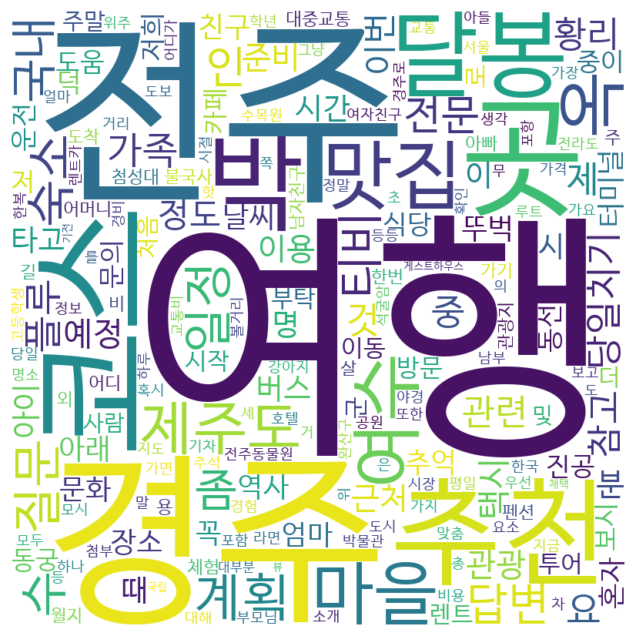

In [69]:
import pandas as pd
import html
import re
from konlpy.tag import Okt
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud


df = pd.read_csv('data/naver_kin.csv', sep='\t')


df['cleaned_total_text'] = df['total_text'].apply(lambda x: html.unescape(x))  
df['cleaned_total_text'] = df['total_text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))  
df['cleaned_total_text'] = df['total_text'].str.lower()  


okt = Okt()
df['nouns'] = df['total_text'].apply(lambda x: [word for word, tag in okt.pos(x) if tag in ('Noun')])

all_nouns = sum(df['nouns'], [])




wordcloud = WordCloud(font_path='C:/Windows/Fonts/한컴 고딕/Hancom Gothic Regular.ttf',
                      background_color='white', width=800, height=800).generate_from_frequencies(nouns_freq)

plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [65]:
# 불용어 처리(불용어지정 + 불용어사전)
from wordcloud import STOPWORDS
불용어 = STOPWORDS | {'전주', '경주', '여행'} # | : 집합합연산자
불용어 = set(['전주', '경주', '여행'])
불용어 = {'전주', '경주', '여행'}
불용어

{'경주', '여행', '전주'}

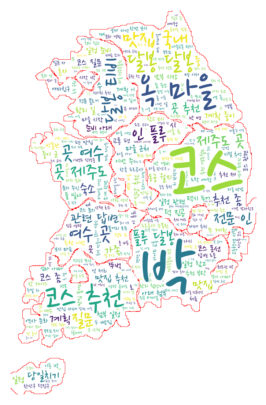

In [67]:
# all_nouns 리스트를 공백으로 구분된 문자열로 변환
text = ' '.join(all_nouns)

# WordCloud 생성
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf',  # 한글 폰트 경로
    background_color='white',  # 배경색
    max_words=300,  # 표시될 단어의 최대 갯수
    colormap='viridis',  # 글씨 컬러맵
    stopwords=불용어,  # 불용어 설정
    mask=mask5,  # 마스크 이미지 (예: 특정 형태로 글자 배치)
    contour_color='red',  # 테두리 색상
    contour_width=1  # 테두리 두께
)

# 공백으로 구분된 문자열을 기반으로 워드클라우드 생성
wordcloud.generate(text)

# 워드클라우드 시각화
plt.figure(figsize=(18, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축을 없애기
plt.show()


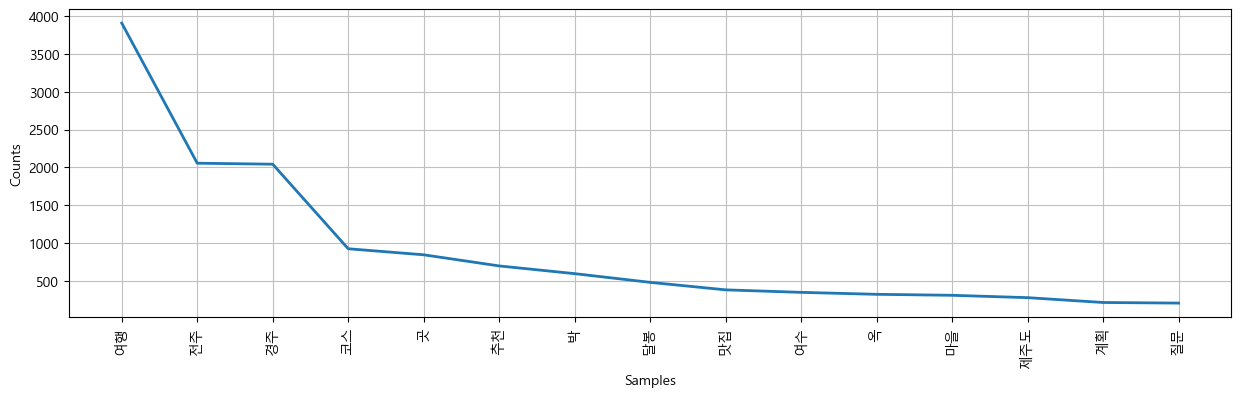

In [70]:
import nltk
data_text = nltk.Text(all_nouns)
plt.figure(figsize=(15,4))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()